# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [14]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = '/content/airline_2019.csv'

## TO DO: read_csv()
df = pd.read_csv(DATA_DIR, usecols=use_cols)

## Check the shape of the loaded data
print(df.shape)

(76616, 29)


#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis

In [15]:
# 1.1 Rename a few columns
df.rename(
    columns={
        'Reporting_Airline':'UniqueCarrier',
        "Flight_Number_Reporting_Airline":"FlightNum",
        "Tail_Number":"TailNum"
    },
    inplace=True
)

print(df.columns)

# 1.2 Random sampling for further analysis
df = df.sample(n=20000, random_state=42)


Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'UniqueCarrier', 'TailNum',
       'FlightNum', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay',
       'TaxiOut', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled',
       'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


### 2. Basic EDA

In [16]:
## Print first 5 rows to check how the data looks like
df.head()

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
66952,2019,5,9,4,DL,N993AT,2182,BNA,DTW,1859,...,0.0,96.0,82.0,67.0,456.0,NaN,NaN,NaN,NaN,NaN
40788,2019,4,13,6,UA,N63890,2152,IAH,SEA,1950,...,0.0,289.0,293.0,243.0,1874.0,14.0,0.0,4.0,0.0,3.0
58392,2019,12,18,3,WN,N8655D,2233,SEA,OAK,1705,...,0.0,120.0,114.0,95.0,672.0,9.0,0.0,0.0,0.0,13.0
42540,2019,7,5,5,AA,N402AN,601,ORD,PHX,1335,...,0.0,222.0,274.0,193.0,1440.0,9.0,0.0,52.0,0.0,0.0
29690,2019,10,4,5,DL,N395DZ,1984,AUS,ATL,600,...,0.0,133.0,131.0,109.0,813.0,NaN,NaN,NaN,NaN,NaN


In [17]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    #
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res

info_df = get_info(df)
info_df

,count,mean,std,min,25%,50%,75%,max,missing_percent,unique_val,var_type
Year,20000.0,2019.000000,0.000000,2019.0,2019.0,2019.0,2019.0,2019.0,0.00000,1,Categorical
Month,20000.0,6.587000,3.395321,1.0,4.0,7.0,10.0,12.0,0.00000,12,Categorical
DayofMonth,20000.0,15.674300,8.723481,1.0,8.0,16.0,23.0,31.0,0.00000,31,Categorical
DayOfWeek,20000.0,3.917050,1.991323,1.0,2.0,4.0,6.0,7.0,0.00000,7,Categorical
FlightNum,20000.0,2553.845100,1799.910189,1.0,1017.0,2154.0,3919.0,7439.0,0.00000,5679,Continuous
CRSDepTime,20000.0,1331.195600,492.551215,5.0,915.0,1323.0,1739.0,2359.0,0.00000,1153,Continuous
DepTime,19666.0,1336.137191,506.848261,1.0,919.0,1329.0,1748.0,2400.0,0.01670,1241,Continuous
DepDelay,19666.0,11.156158,52.217236,-42.0,-5.0,-2.0,7.0,1855.0,0.01670,371,Continuous
TaxiOut,19653.0,17.419020,9.918825,2.0,11.0,15.0,20.0,147.0,0.01735,111,Continuous
TaxiIn,19637.0,7.737129,6.115498,1.0,4.0,6.0,9.0,147.0,0.01815,76,Categorical


### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

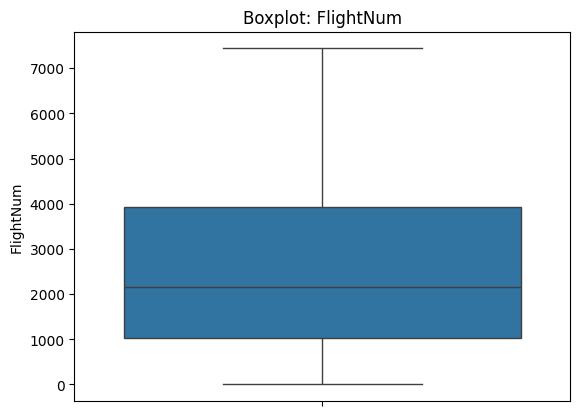

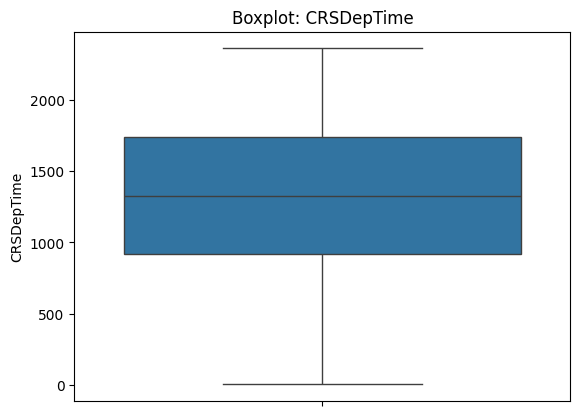

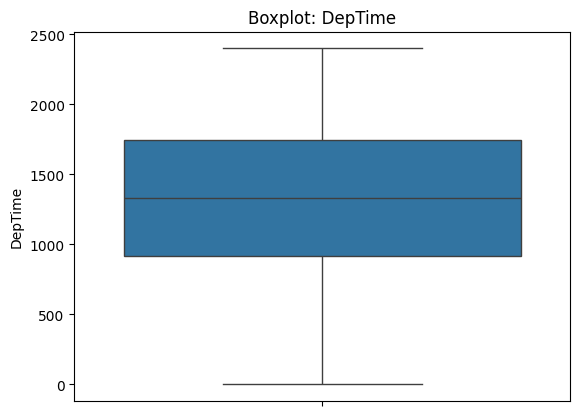

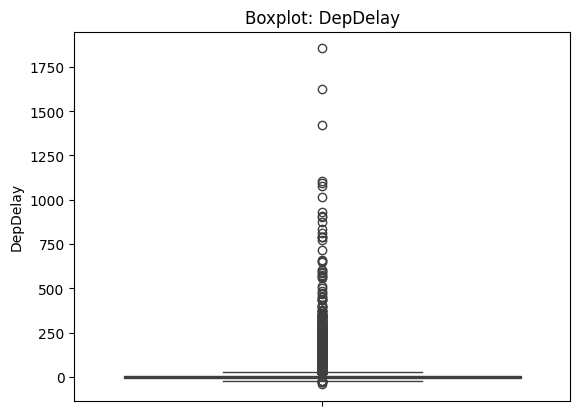

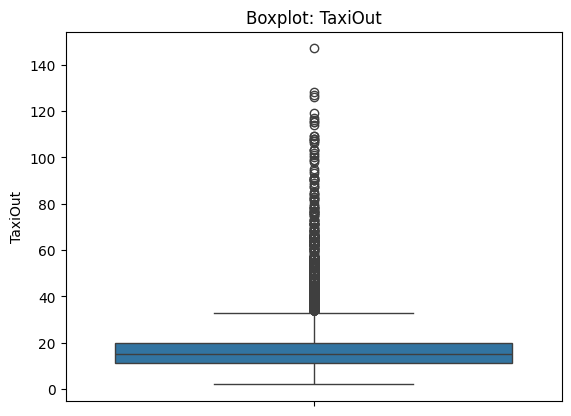

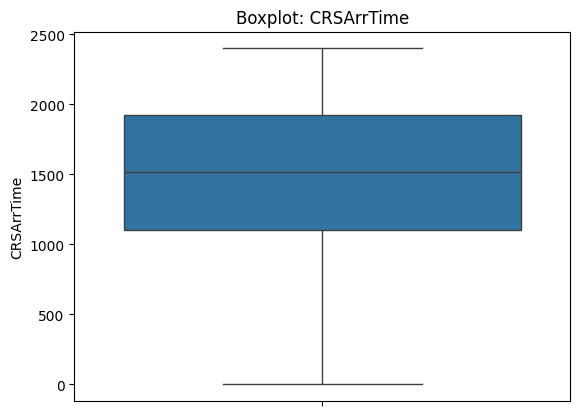

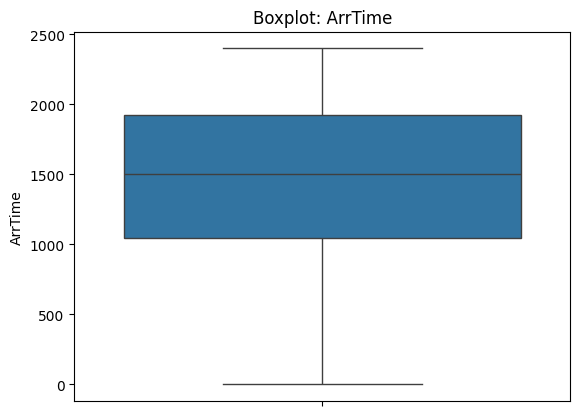

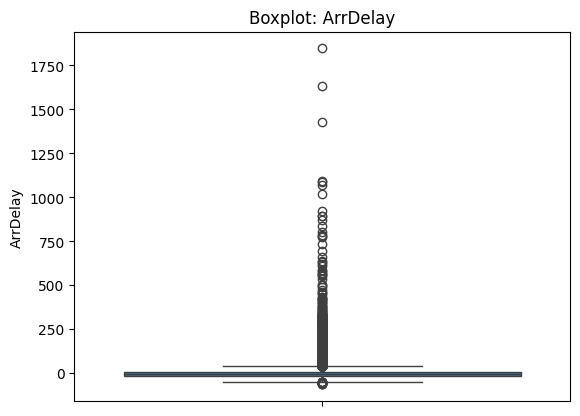

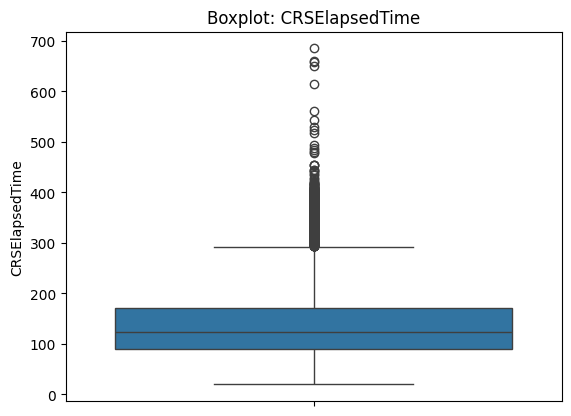

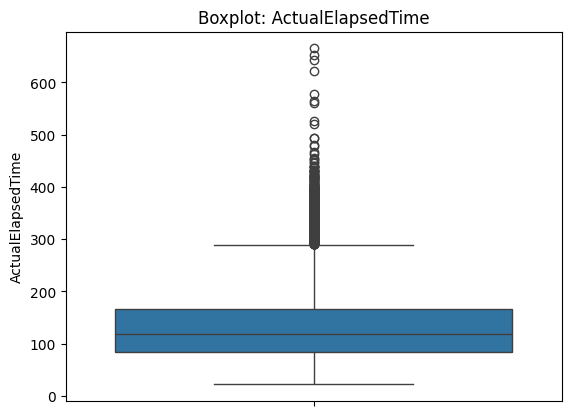

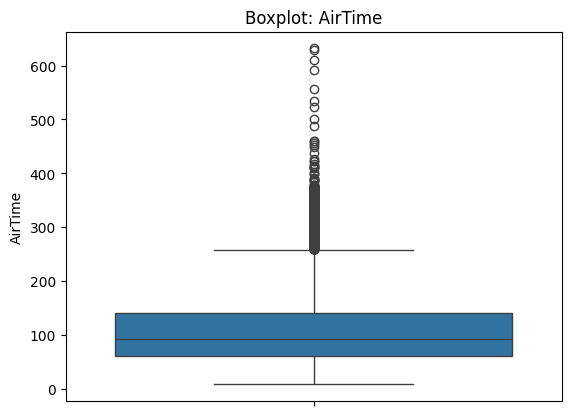

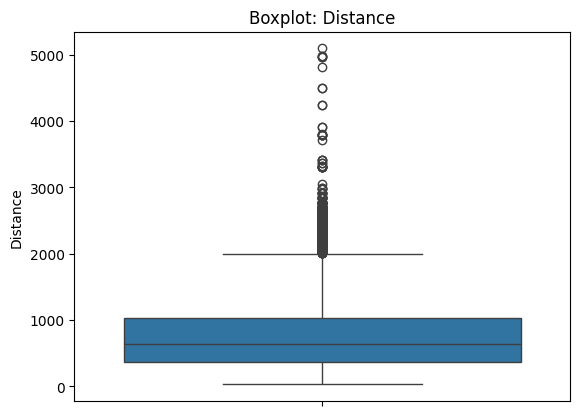

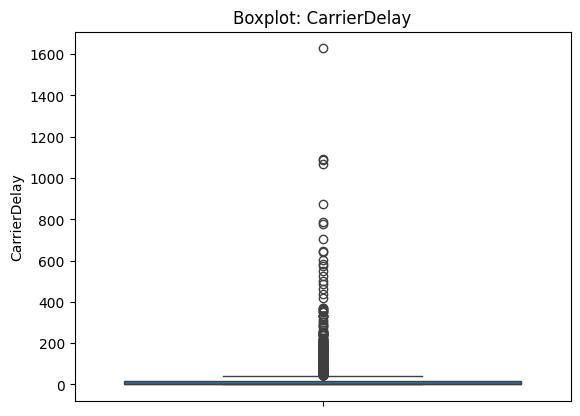

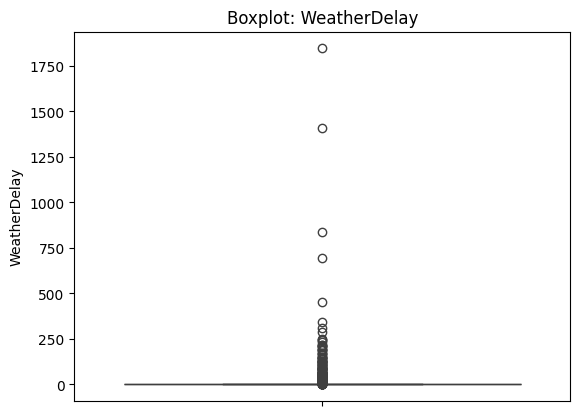

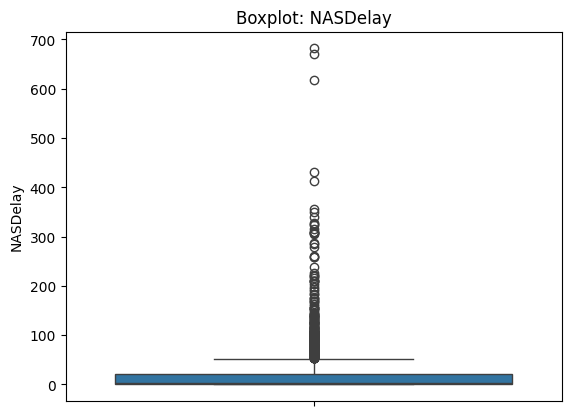

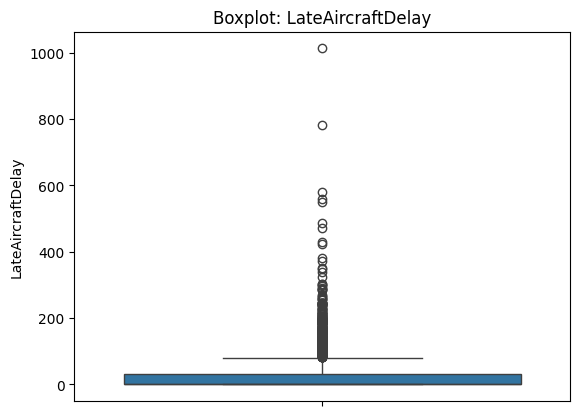

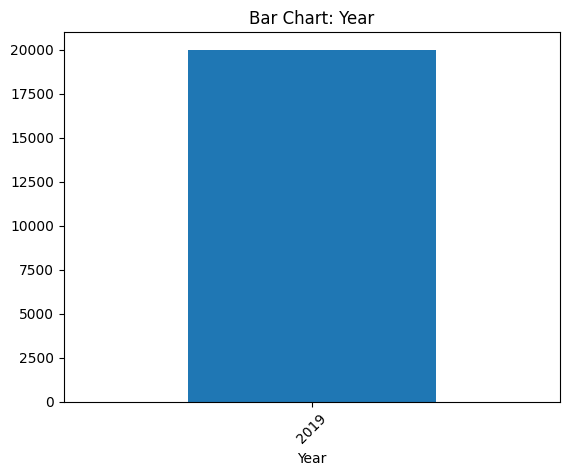

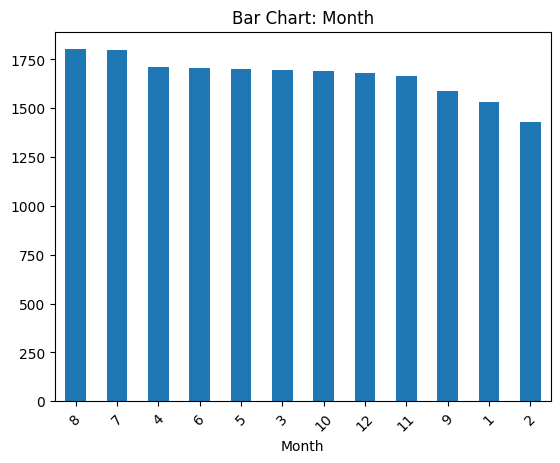

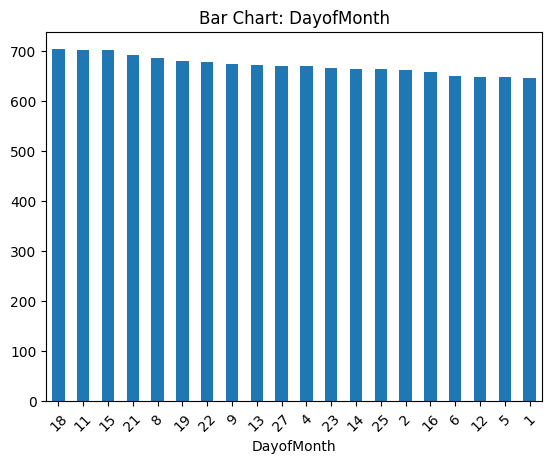

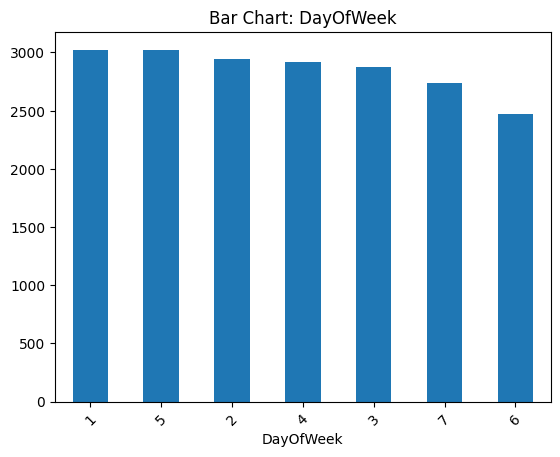

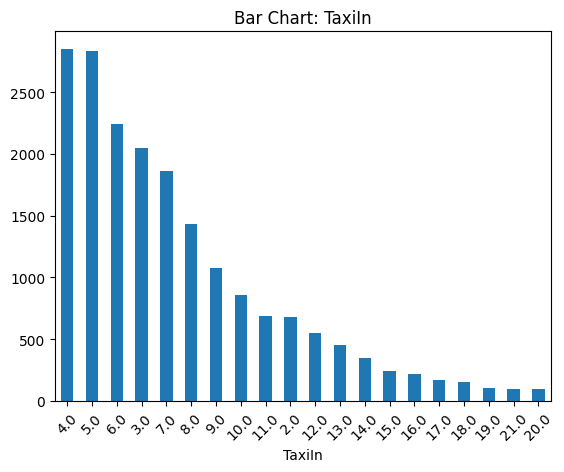

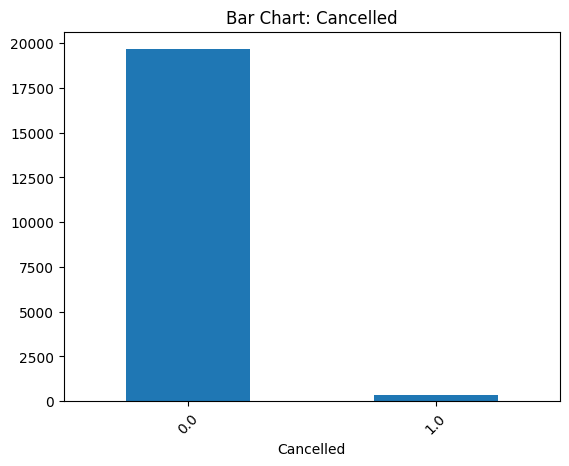

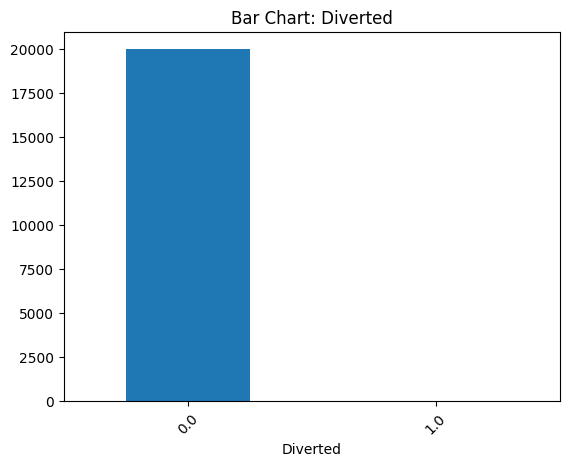

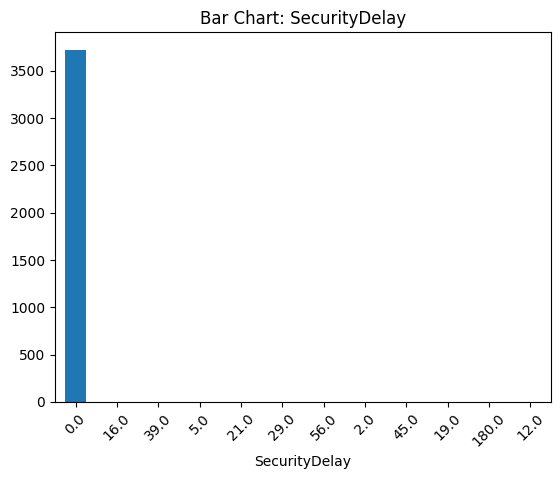

In [18]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = info_df[info_df['var_type'] == 'Continuous'].index.tolist()
categorical_cols = info_df[info_df['var_type'] == 'Categorical'].index.tolist()

for col in continuous_cols:
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.show()

for col in categorical_cols:
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f'Bar Chart: {col}')
    plt.xticks(rotation=45)
    plt.show()

In [19]:
## 3.2 Calculate the missing value percentage of each column
missing = df.isnull().mean() * 100

print('Missing value percentage per column:')
print(missing)

Missing value percentage per column:
Year                  0.000
Month                 0.000
DayofMonth            0.000
DayOfWeek             0.000
UniqueCarrier         0.000
TailNum               0.235
FlightNum             0.000
Origin                0.000
Dest                  0.000
CRSDepTime            0.000
DepTime               1.670
DepDelay              1.670
TaxiOut               1.735
TaxiIn                1.815
CRSArrTime            0.000
ArrTime               1.815
ArrDelay              1.965
Cancelled             0.000
CancellationCode     98.245
Diverted              0.000
CRSElapsedTime        0.000
ActualElapsedTime     1.965
AirTime               1.965
Distance              0.000
CarrierDelay         81.330
WeatherDelay         81.330
NASDelay             81.330
SecurityDelay        81.330
LateAircraftDelay    81.330
dtype: float64


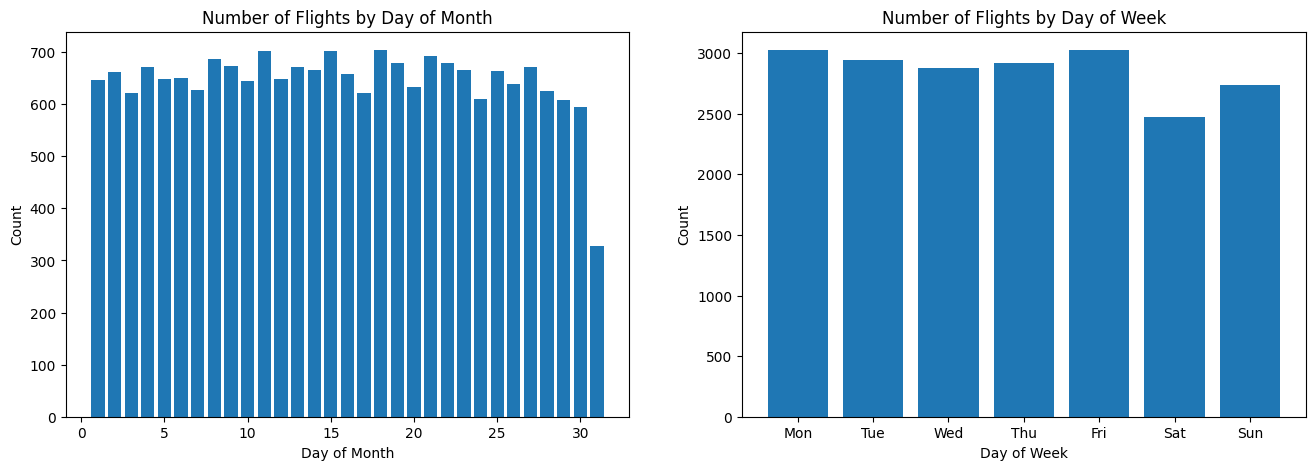

In [20]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek
## Visualize with Barchart

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Flights by DayofMonth
day_of_month_counts = df['DayofMonth'].value_counts().sort_index()
axes[0].bar(day_of_month_counts.index, day_of_month_counts.values)
axes[0].set_title('Number of Flights by Day of Month')
axes[0].set_xlabel('Day of Month')
axes[0].set_ylabel('Count')

# Flights by DayOfWeek
day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_of_week_counts = df['DayOfWeek'].value_counts().sort_index()
axes[1].bar([day_labels[d] for d in day_of_week_counts.index], day_of_week_counts.values)
axes[1].set_title('Number of Flights by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Count')

plt.show()

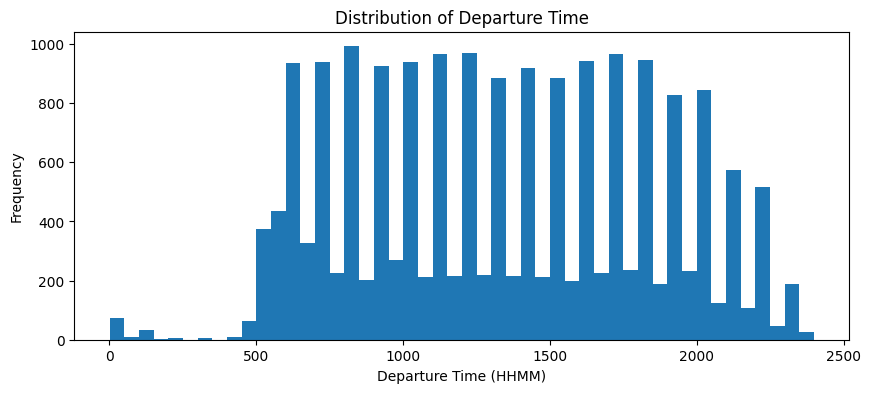

In [21]:
## 3.4.1 Histogram of Departure Time
plt.figure(figsize=(10, 4))
df['DepTime'].dropna().plot(kind='hist', bins=48)
plt.title('Distribution of Departure Time')
plt.xlabel('Departure Time (HHMM)')
plt.ylabel('Frequency')
plt.show()

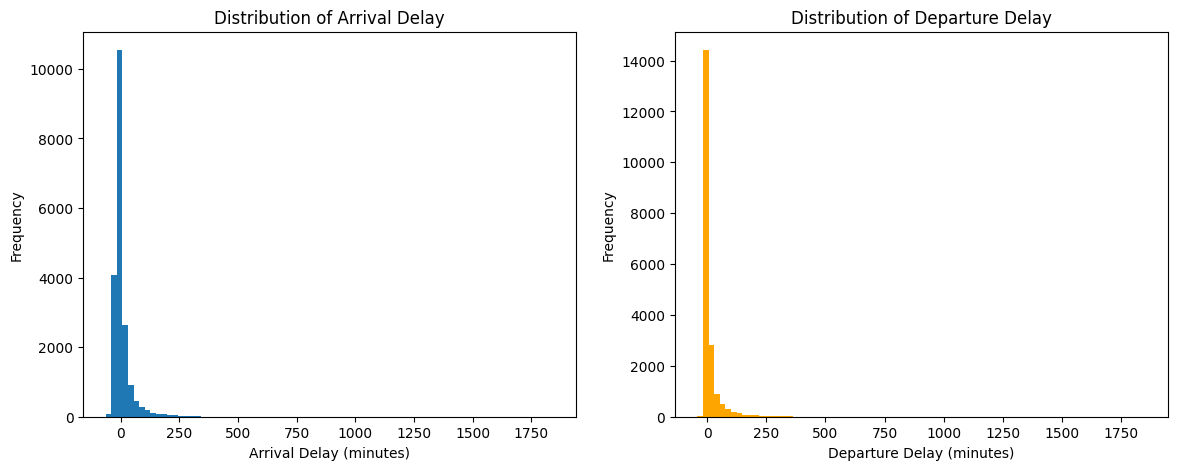

In [22]:
## 3.4.2 Histogram of arrival and departure delays
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ArrDelay'].dropna().plot(kind='hist', bins=80, ax=axes[0])
axes[0].set_title('Distribution of Arrival Delay')
axes[0].set_xlabel('Arrival Delay (minutes)')
axes[0].set_ylabel('Frequency')

df['DepDelay'].dropna().plot(kind='hist', bins=80, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Departure Delay')
axes[1].set_xlabel('Departure Delay (minutes)')
axes[1].set_ylabel('Frequency')

plt.show()

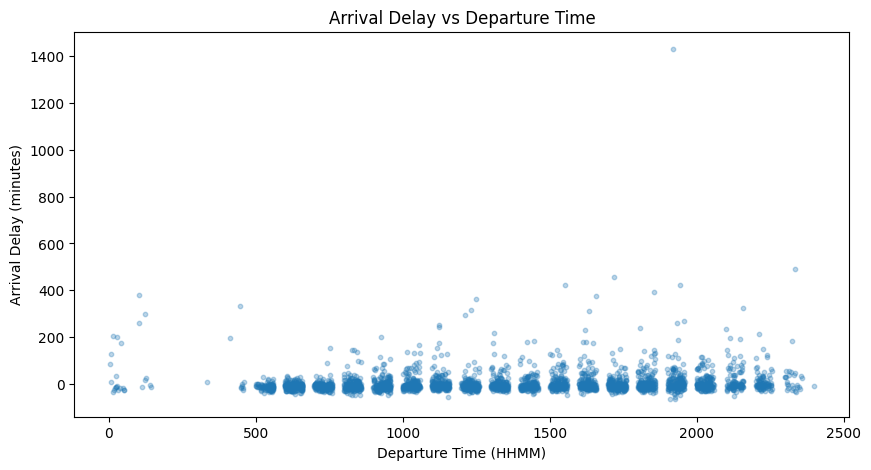

In [23]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot

sample = df[['DepTime', 'ArrDelay']].dropna().sample(n=min(3000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['DepTime'], sample['ArrDelay'], alpha=0.3, s=10)
plt.title('Arrival Delay vs Departure Time')
plt.xlabel('Departure Time (HHMM)')
plt.ylabel('Arrival Delay (minutes)')
plt.show()

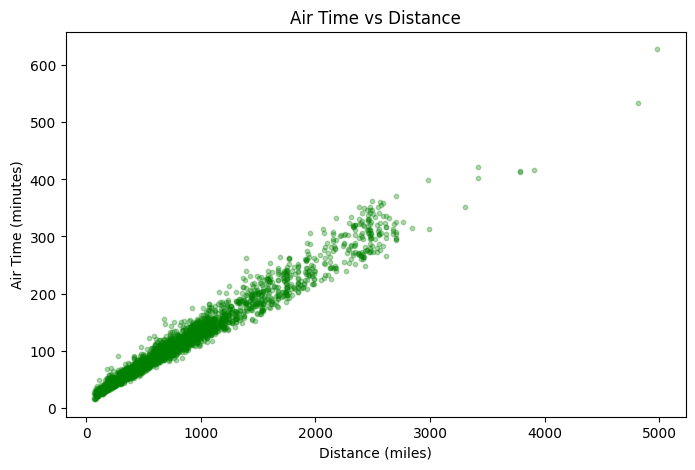

In [24]:
## 3.5.2 bivariate analysis: distance and airtimes
sample2 = df[['Distance', 'AirTime']].dropna().sample(n=min(3000, len(df)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample2['Distance'], sample2['AirTime'], alpha=0.3, s=10, color='green')
plt.title('Air Time vs Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Air Time (minutes)')
plt.show()

### 4. Feature engineering and cleaning

In [25]:
## 4.1 creating a categorical column for weekday
## {      1: 'Monday',
##        2: 'Tuesday',
##        3: 'Wednesday',
##        4: 'Thursday',
##        5: 'Friday',
##        6: 'Saturday',
##        7: 'Sunday'}

day_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

df['DayOfWeekName'] = df['DayOfWeek'].map(day_map)

print(df[['DayOfWeek', 'DayOfWeekName']].head(10))

       DayOfWeek DayOfWeekName
66952          4      Thursday
40788          6      Saturday
58392          3     Wednesday
42540          5        Friday
29690          5        Friday
39289          5        Friday
66402          5        Friday
68965          6      Saturday
59444          6      Saturday
34238          1        Monday


In [26]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)

for col in ['ArrDelay', 'DepDelay']:
    clipped_col = col + '_clipped'
    log_col = col + '_log'
    df[clipped_col] = df[col].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
    df[log_col] = np.log1p(df[clipped_col])

print(df[['ArrDelay', 'ArrDelay_clipped', 'ArrDelay_log',
          'DepDelay', 'DepDelay_clipped', 'DepDelay_log']].head(10))

       ArrDelay  ArrDelay_clipped  ArrDelay_log  DepDelay  DepDelay_clipped  \
66952     -15.0               0.0      0.000000      -1.0               0.0   
40788      21.0              21.0      3.091042      17.0              17.0   
58392      22.0              22.0      3.135494      28.0              28.0   
42540      61.0              61.0      4.127134       9.0               9.0   
29690      -5.0               0.0      0.000000      -3.0               0.0   
39289     -10.0               0.0      0.000000      -3.0               0.0   
66402      -2.0               0.0      0.000000       0.0               0.0   
68965     -21.0               0.0      0.000000      -5.0               0.0   
59444      -3.0               0.0      0.000000      -8.0               0.0   
34238      -4.0               0.0      0.000000      -4.0               0.0   

       DepDelay_log  
66952      0.000000  
40788      2.890372  
58392      3.367296  
42540      2.302585  
29690      0.000000 

In [27]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75
def hhmm_to_decimal(t):
    if pd.isnull(t):
        return np.nan
    t = int(t)
    hours = t // 100
    minutes = t % 100
    return hours + minutes / 60

df['DecimalDepTime'] = df['CRSDepTime'].apply(hhmm_to_decimal)

print(df[['CRSDepTime', 'DecimalDepTime']].head(10))

       CRSDepTime  DecimalDepTime
66952        1859       18.983333
40788        1950       19.833333
58392        1705       17.083333
42540        1335       13.583333
29690         600        6.000000
39289         958        9.966667
66402         926        9.433333
68965        1417       14.283333
59444         612        6.200000
34238        1005       10.083333


count    19607.000000
mean       404.683350
std         71.003990
min         98.048780
25%        360.962594
50%        410.886076
75%        452.394690
max        620.564516
Name: speed, dtype: float64


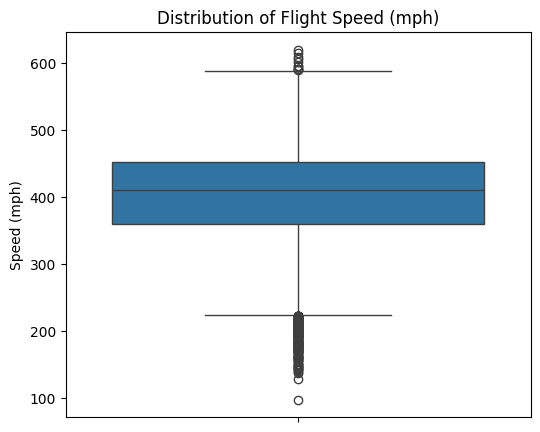

In [28]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
df['speed'] = df['Distance'] / df['AirTime'] * 60

print(df['speed'].describe())

## boxplots of average speeds
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['speed'].dropna())
plt.title('Distribution of Flight Speed (mph)')
plt.ylabel('Speed (mph)')
plt.show()

In [29]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
fast_flights = df[df['speed'] > 650]
total_with_speed = df['speed'].notna().sum()
proportion = len(fast_flights) / total_with_speed

print(f'Flights with speed > 650 mph: {len(fast_flights)}')
print(f'Total flights with valid speed: {total_with_speed}')
print(f'Proportion: {proportion:.4f} ({proportion*100:.2f}%)')

Flights with speed > 650 mph: 0
Total flights with valid speed: 19607
Proportion: 0.0000 (0.00%)


### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [30]:
## Save transformed data
df.to_csv('airline_2019_transformed.csv', index=False)
print('Saved as CSV: airline_2019_transformed.csv')

Saved as CSV: airline_2019_transformed.csv
